In [ ]:
"""This code predicts ad-click behavior using logistic regression and evaluates model performance with classification metrics and visualizations."""

# 1. Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

In [25]:
df = pd.read_csv('advertising.csv')
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [26]:
print(df.columns)

Index(['Daily Time Spent on Site', 'Age', 'Area Income',
       'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country',
       'Timestamp', 'Clicked on Ad'],
      dtype='object')


In [27]:
df_clean = df.drop(['Ad Topic Line', 'City', 'Country', 'Timestamp'], axis=1)

In [28]:
X = df_clean.drop('Clicked on Ad', axis=1)
y = df_clean['Clicked on Ad']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [32]:
y_pred = model.predict(X_test_scaled)

In [33]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

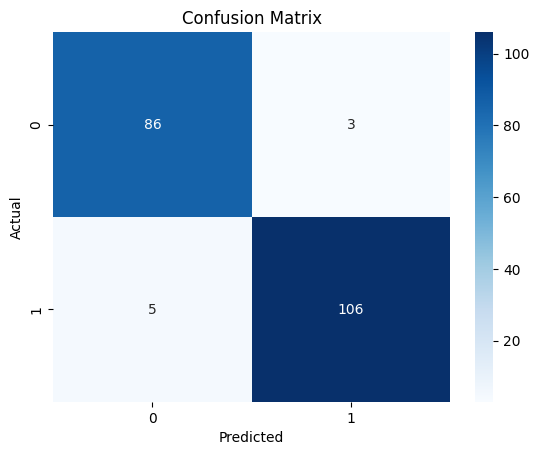

In [34]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [35]:
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

In [36]:
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")
print("\n--- Classification Metrics ---")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Error Rate   : {error_rate:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")

True Positives (TP): 106
False Positives (FP): 3
True Negatives (TN): 86
False Negatives (FN): 5

--- Classification Metrics ---
Accuracy     : 0.9600
Error Rate   : 0.0400
Precision    : 0.9725
Recall       : 0.9550


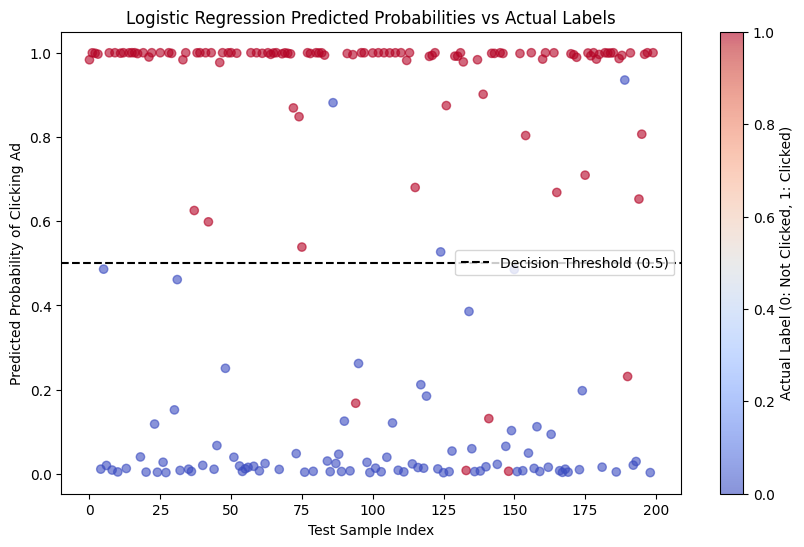

In [43]:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_pred_proba, c=y_test, cmap='coolwarm', alpha=0.6)
plt.axhline(y=0.5, color='black', linestyle='--', label='Decision Threshold (0.5)')
plt.colorbar(label='Actual Label (0: Not Clicked, 1: Clicked)')
plt.xlabel('Test Sample Index')
plt.ylabel('Predicted Probability of Clicking Ad')
plt.title('Logistic Regression Predicted Probabilities vs Actual Labels')
plt.legend()
plt.show()

In [ ]:
"""1–7: Importing libraries
import pandas as pd
→ Used for data loading and manipulation.

import numpy as np
→ Used for numerical computations.

import seaborn as sns
→ Used for data visualization (e.g., heatmaps).

import matplotlib.pyplot as plt
→ Used for plotting graphs.

from sklearn.model_selection import train_test_split
→ Splits data into training and testing sets.

from sklearn.linear_model import LogisticRegression
→ Imports the logistic regression model.

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
→ Imports metrics to evaluate classification performance.

from sklearn.preprocessing import StandardScaler
→ Used to normalize feature scales.

from sklearn.metrics import roc_curve, roc_auc_score
→ Imports tools for ROC analysis.

10–11: Load and preview the dataset
df = pd.read_csv('advertising.csv')
→ Loads the dataset from a CSV file.

df.head()
→ Displays the first 5 rows of the dataset.

12–13: Show all column names
print(df.columns)
→ Prints the names of all columns in the dataset.

14–16: Drop unnecessary features
df_clean = df.drop(['Ad Topic Line', 'City', 'Country', 'Timestamp'], axis=1)
→ Removes irrelevant or non-numeric columns.

17–18: Split into features and target
X = df_clean.drop('Clicked on Ad', axis=1)
→ Feature matrix without the target column.

y = df_clean['Clicked on Ad']
→ Target variable: 1 if clicked, 0 otherwise.

19: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
→ 80% training and 20% testing split with reproducibility.

20–22: Scale the data
scaler = StandardScaler()
→ Initializes the scaler to standardize features.

X_train_scaled = scaler.fit_transform(X_train)
→ Fits and transforms the training data.

X_test_scaled = scaler.transform(X_test)
→ Transforms the test data using the same scaling.

23–24: Train the logistic regression model
model = LogisticRegression()
→ Initializes the logistic regression model.

model.fit(X_train_scaled, y_train)
→ Trains the model on scaled training data.

25: Make predictions
y_pred = model.predict(X_test_scaled)
→ Predicts labels (0 or 1) for the test set.

26–28: Create and display confusion matrix
cm = confusion_matrix(y_test, y_pred)
→ Builds a 2×2 matrix of prediction results.

tn, fp, fn, tp = cm.ravel()
→ Extracts counts of true/false positives/negatives.

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
→ Plots the confusion matrix.

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()
→ Adds labels and displays the heatmap.

33–36: Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)
→ Calculates correct predictions over all.

error_rate = 1 - accuracy
→ Inverse of accuracy.

precision = precision_score(y_test, y_pred)
→ True Positives / (True Positives + False Positives)

recall = recall_score(y_test, y_pred)
→ True Positives / (True Positives + False Negatives)

37–42: Display evaluation results
print(f"True Positives (TP): {tp}")

print(f"False Positives (FP): {fp}")

print(f"True Negatives (TN): {tn}")

print(f"False Negatives (FN): {fn}")

print("\n--- Classification Metrics ---")

print(f"Accuracy : {accuracy:.4f}")

print(f"Error Rate : {error_rate:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall : {recall:.4f}")

46–51: Visualize predicted probabilities
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
→ Gets probability of class 1 (clicked ad).

plt.figure(figsize=(10, 6))

plt.scatter(range(len(y_test)), y_pred_proba, c=y_test, cmap='coolwarm', alpha=0.6)
→ Scatter plot colored by actual labels.

plt.axhline(y=0.5, color='black', linestyle='--', label='Decision Threshold (0.5)')
→ Adds a decision boundary line.

plt.colorbar(label='Actual Label (0: Not Clicked, 1: Clicked)')
→ Adds color scale legend.

plt.xlabel('Test Sample Index')

plt.ylabel('Predicted Probability of Clicking Ad')

plt.title('Logistic Regression Predicted Probabilities vs Actual Labels')

plt.legend()

plt.show()
→ Finalize and display the plot."""